In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


df = pd.read_csv('Agri_Data_Cleaned.csv')
target = "NDVI_Season_Mean"


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
df.head()

,AP_Ratio,District,Season,Avg_Humidity,Crop_Name,Transplant,Growth,NDVI_Season_Mean,EVI,LAI,FPAR,Soil_Moisture_mm,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Silt,CN_Ratio,Dominant_Soil_Texture,Rainfall,Temp_Mean,Temp_Max,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,LST_C
0,2.9175,Gazipur,Kharif 1,65.0000,Taramind,February,March To April,0.3007,0.5490,1.0555,0.0185,25.8147,788.0503,5.7400,16.6800,1.3600,33.7900,33.0400,12.2700,Loamy,"1,035.8500",25.7449,37.6800,16.4100,46,2.4247,6.3000,40.2300,24.5695
1,0.9561,Munshiganj,Kharif 1,72.5000,Aus,March,April To July,0.3475,0.6378,1.0719,0.0319,28.6055,897.4539,5.3200,19.2800,1.7700,34.8100,36.8700,10.8800,Loamy,899.6400,29.7438,37.7300,15.4800,51,2.9399,6.0800,30.2500,27.5377
2,2.5255,Brahmanbaria,Kharif 2,67.5000,Tobacco,October,Nov To Feb,0.3110,0.5702,0.9584,0.0243,24.6311,757.6894,5.4900,25.6900,2.8300,33.8100,38.5500,9.0700,Loamy,"1,124.1600",27.6812,33.8700,18.7200,0,1.6234,5.6600,40.6100,27.9589
3,0.9546,Khagrachari,Kharif 1,72.5000,Aus,March,April To July,0.3981,0.6884,1.3651,0.0280,28.1302,618.0393,5.6800,16.7400,1.5400,30.2800,37.4200,10.8800,Loamy,"1,103.4000",26.3564,38.7000,12.5300,25,0.2013,0.9500,41.8600,25.3887
4,3.4513,Sirajganj,Rabi,60.0000,Maize 2,December,Jan To March,0.4008,0.6831,1.5209,0.0332,7.7033,939.4532,6.1700,22.3800,1.3300,41.3400,37.2800,16.8100,Clayey,85.7200,19.2166,30.4000,8.2300,0,1.3789,4.3700,4.4600,23.3376


# Data Visualization

**Mục tiêu:** Khám phá dữ liệu và tìm các tín hiệu có thể hỗ trợ bài toán regression dự đoán `NDVI_Season_Mean`.

Trong notebook này, mỗi kết quả EDA sẽ được liên hệ với một quyết định ở bước preprocessing hoặc modeling. Các kết luận chỉ mô tả mối liên hệ trong dataset, không được diễn giải như quan hệ nhân quả nếu chưa có thiết kế nghiên cứu phù hợp.

## 3. Phân phối biến mục tiêu NDVI

`NDVI_Season_Mean` phản ánh mức độ xanh và hoạt động của thảm thực vật theo mùa. Giá trị cao thường đi kèm thảm thực vật phát triển tốt hơn, nhưng cần diễn giải cùng với loại cây, mùa vụ, khu vực và thời điểm thu thập dữ liệu.

count   9,998.0000
mean        0.3876
std         0.1039
min         0.0000
25%         0.3278
50%         0.3931
75%         0.4517
max         0.7796
Name: NDVI_Season_Mean, dtype: float64


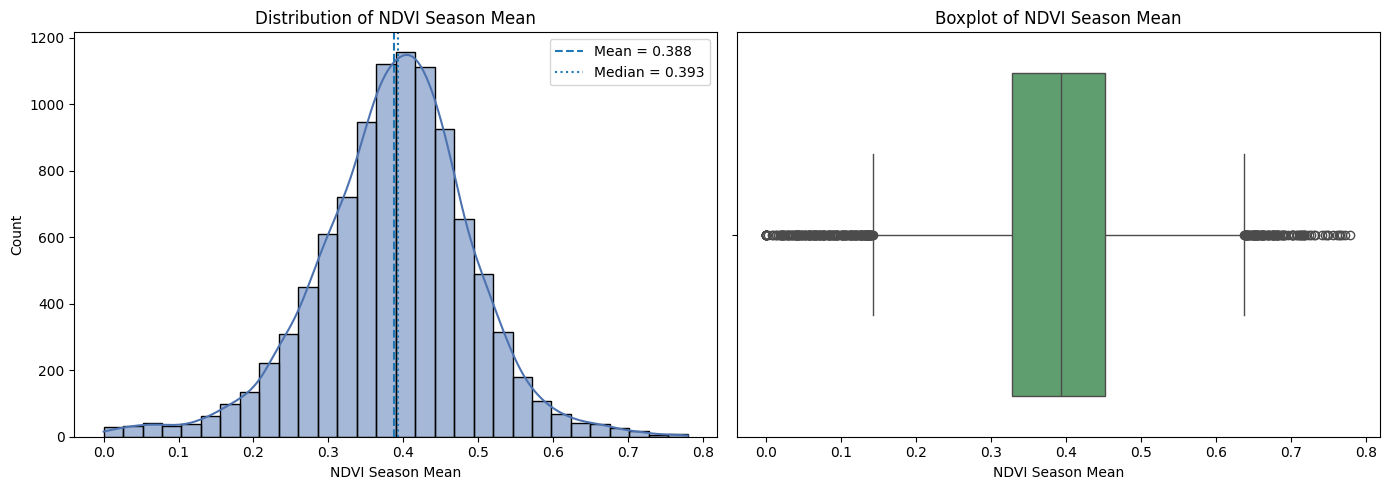

In [15]:
print(df[target].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target], bins=30, kde=True, color="#4C72B0", ax=axes[0])
axes[0].axvline(
    df[target].mean(),
    linestyle="--",
    label=f"Mean = {df[target].mean():.3f}"
)
axes[0].axvline(
    df[target].median(),
    linestyle=":",
    label=f"Median = {df[target].median():.3f}"
)
axes[0].set_title("Distribution of NDVI Season Mean")
axes[0].set_xlabel("NDVI Season Mean")
axes[0].legend()

sns.boxplot(x=df[target], color="#55A868", ax=axes[1])
axes[1].set_title("Boxplot of NDVI Season Mean")
axes[1].set_xlabel("NDVI Season Mean")

plt.tight_layout()
plt.show()

**Nhận xét**

- Mean và median của NDVI đều xấp xỉ 0.39, cho thấy target không lệch mạnh.
- Phần lớn quan sát tập trung quanh khoảng 0.33–0.45.
- Vì target tương đối cân đối và có ý nghĩa rõ trên thang gốc, chưa có lý do mạnh để log-transform target.
- Khi modeling, có thể báo cáo MAE trực tiếp theo đơn vị NDVI, ví dụ MAE = 0.03 nghĩa là dự đoán lệch trung bình khoảng 0.03 đơn vị NDVI.

## 4. NDVI theo mùa vụ

Mùa vụ là biến quan trọng vì khí hậu, lượng mưa, nhiệt độ và danh mục cây trồng thay đổi đáng kể giữa các mùa.

,count,mean,median,std,min,max
Season,,,,,,
Kharif 1,3326,0.3121,0.3159,0.0875,0.0000,0.5273
Kharif 2,3892,0.4176,0.4200,0.0940,0.0071,0.7020
Rabi,2780,0.4362,0.4286,0.0826,0.1862,0.7796


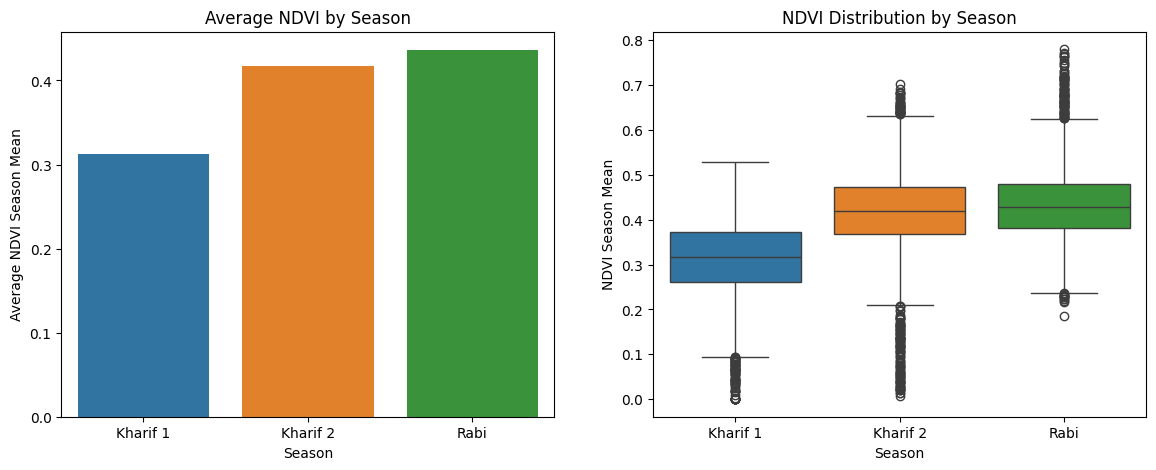

In [35]:
season_summary = (df.groupby("Season")[target].agg(count="count", mean="mean", median="median", std="std", min="min", max="max"))
display(season_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=season_summary.reset_index(),
    x="Season",
    y="mean",
    hue="Season",
    dodge=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Average NDVI by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average NDVI Season Mean")

sns.boxplot(
    data=df,
    x="Season",
    y=target,
    hue="Season",
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("NDVI Distribution by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("NDVI Season Mean")

plt.show()

**Nhận xét**

- NDVI trung bình cao nhất ở `Rabi`, tiếp theo là `Kharif 2`, và thấp nhất ở `Kharif 1`.
- Đây là khác biệt mô tả giữa các nhóm, chưa chứng minh bản thân Season gây ra thay đổi NDVI.
- Season đồng thời đi kèm với loại cây và điều kiện môi trường khác nhau, nên có thể đóng vai trò biến gây nhiễu hoặc biến tương tác.

**Liên hệ model:** Giữ `Season` trong feature set. Tree-based models là lựa chọn hợp lý vì có thể học interaction giữa Season và các biến thời tiết mà không cần chỉ định công thức tuyến tính.

## 5. NDVI theo cây trồng và sự phụ thuộc Crop–Season

So sánh theo cây trồng giúp phát hiện nhóm có NDVI cao/thấp. Tuy nhiên, cần kiểm tra xem `Crop_Name` có độc lập với `Season` hay không trước khi diễn giải.

,count,mean,median,std
Crop_Name,,,,
Banana,139,0.5112,0.5060,0.0717
Boro,139,0.4928,0.4829,0.0747
Palmyra Palm,139,0.4922,0.4829,0.0707
Lemon,139,0.4899,0.4747,0.0820
Betelnut,139,0.4884,0.4891,0.0792
Black Berry,139,0.4783,0.4758,0.0860
Green Palmyra,139,0.4711,0.4742,0.0855
Boroi,139,0.4708,0.4694,0.0776
Jamrul,139,0.4707,0.4726,0.0888


,count,mean,median,std
Crop_Name,,,,
Green Papaya,138,0.3109,0.3128,0.0754
Aus,138,0.3096,0.3118,0.0858
Maize 1,139,0.3003,0.3015,0.0749
Lady’s Finger,139,0.2801,0.2873,0.0903
Chalkumra,138,0.2759,0.2687,0.0787
Beans,138,0.2591,0.2597,0.0853
Jhinga,139,0.2585,0.2633,0.0854
Kakrol,139,0.2582,0.2612,0.0752
Mukhi Kachu,139,0.2507,0.2498,0.0860


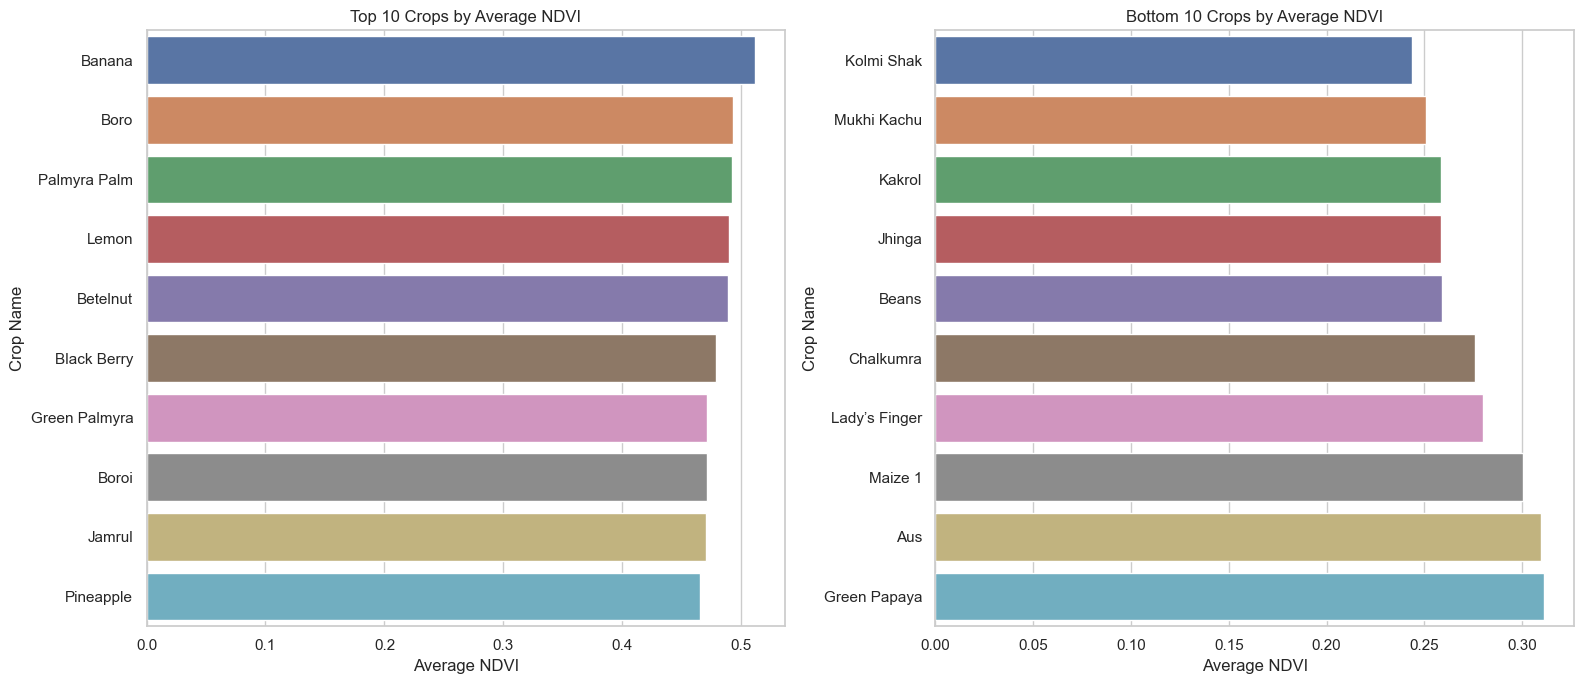

In [ ]:
crop_summary = (
    df_eda.groupby("Crop_Name")[target]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

display(crop_summary.head(10))
display(crop_summary.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_crops = crop_summary.head(10).reset_index()
sns.barplot(
    data=top_crops,
    x="mean",
    y="Crop_Name",
    hue="Crop_Name",
    dodge=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 10 Crops by Average NDVI")
axes[0].set_xlabel("Average NDVI")
axes[0].set_ylabel("Crop Name")

bottom_crops = crop_summary.tail(10).sort_values("mean").reset_index()
sns.barplot(
    data=bottom_crops,
    x="mean",
    y="Crop_Name",
    hue="Crop_Name",
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Bottom 10 Crops by Average NDVI")
axes[1].set_xlabel("Average NDVI")
axes[1].set_ylabel("Crop Name")

plt.tight_layout()
plt.show()

In [ ]:
crop_context = (
    df_eda.groupby("Crop_Name")
    .agg(
        row_count=(target, "size"),
        number_of_seasons=("Season", "nunique"),
        number_of_growth_groups=("Growth", "nunique"),
        dominant_season=("Season", lambda s: s.mode().iat[0]),
        dominant_growth=("Growth", lambda s: s.mode().iat[0]),
    )
    .sort_values(["number_of_seasons", "row_count"])
)

print("Distribution of number of seasons per crop:")
display(crop_context["number_of_seasons"].value_counts().sort_index().to_frame("crop_count"))

print("Distribution of number of growth groups per crop:")
display(crop_context["number_of_growth_groups"].value_counts().sort_index().to_frame("crop_count"))

display(crop_context.head(15))

Distribution of number of seasons per crop:


,crop_count
number_of_seasons,
1,72


Distribution of number of growth groups per crop:


,crop_count
number_of_growth_groups,
1,72


,row_count,number_of_seasons,number_of_growth_groups,dominant_season,dominant_growth
Crop_Name,,,,,
Taramind,137,1,1,Kharif 1,March To April
Amra,138,1,1,Kharif 1,June To August
Aus,138,1,1,Kharif 1,April To July
Beans,138,1,1,Kharif 1,July To Nov
Chalkumra,138,1,1,Kharif 1,April To July
Dalim,138,1,1,Kharif 1,No Need To Do
Date Palm,138,1,1,Kharif 1,No Need To Do
Green Coconut,138,1,1,Kharif 1,June To August
Green Papaya,138,1,1,Kharif 1,June To August


**Nhận xét**

- Các bảng xếp hạng crop chỉ mang tính mô tả.
- Trong dataset sau khi loại `#REF!`, mỗi `Crop_Name` chỉ xuất hiện trong đúng **một Season** và một nhóm `Growth`.
- Vì vậy, dữ liệu không cho phép tách riêng hoàn toàn “crop effect” khỏi “season/growth effect”. Ví dụ, NDVI cao của Banana có thể phản ánh đồng thời loại cây, mùa vụ, khu vực và điều kiện môi trường đi kèm.

**Liên hệ model:** Có thể giữ cả Crop và Season để tối ưu prediction, nhưng không nên diễn giải feature importance như tác động nhân quả riêng biệt. Cần lưu ý thông tin trùng lặp giữa các categorical features.

## 6. NDVI theo khu vực

District có thể đại diện cho khác biệt về đất, khí hậu, địa hình, canh tác và chất lượng dữ liệu. Vì mục tiêu có thể là tổng quát hóa sang khu vực mới, cần xem cả mức NDVI và số trường hợp NDVI bằng 0 theo district.

,count,mean,median,std,zero_ndvi_count,zero_ndvi_rate
District,,,,,,
Sunamganj,160,0.1728,0.0713,0.1803,12,0.0750
Kishoreganj,147,0.2309,0.1804,0.1203,0,0.0000
Bhola,147,0.2560,0.2527,0.0445,0,0.0000
Netrokona,173,0.2730,0.2995,0.1120,0,0.0000
Sirajganj,162,0.2854,0.2726,0.0727,0,0.0000
Kurigram,157,0.3063,0.3167,0.0788,0,0.0000
Dhaka,150,0.3218,0.3194,0.0641,0,0.0000
Gaibandha,149,0.3235,0.3337,0.0633,0,0.0000
Sylhet,149,0.3280,0.3731,0.1340,0,0.0000


,count,mean,median,std,zero_ndvi_count,zero_ndvi_rate
District,,,,,,
Chuadanga,151,0.4519,0.4375,0.0692,0,0.0000
Pirojpur,135,0.4577,0.4665,0.0704,0,0.0000
Jhenaidah,150,0.4582,0.4576,0.0614,0,0.0000
Chattogram,154,0.4699,0.4770,0.0689,0,0.0000
Meherpur,169,0.4708,0.4646,0.0663,0,0.0000
Gopalganj,165,0.4770,0.4790,0.0642,0,0.0000
Jhallokati,154,0.4862,0.4983,0.0668,0,0.0000
Rangamati,179,0.5264,0.5543,0.1027,0,0.0000
Khagrachari,152,0.5528,0.5835,0.1130,0,0.0000


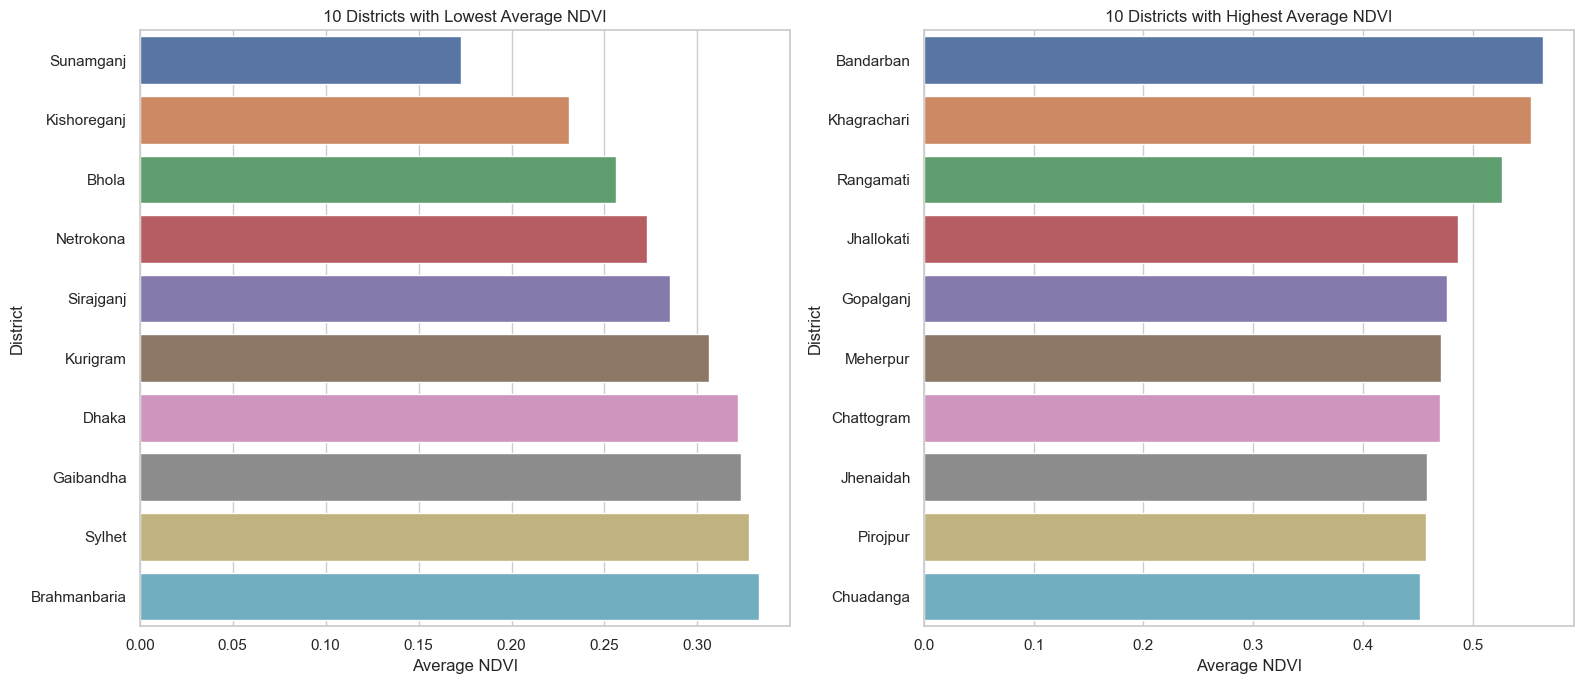

In [ ]:
district_summary = (
    df_eda.groupby("District")
    .agg(
        count=(target, "size"),
        mean=(target, "mean"),
        median=(target, "median"),
        std=(target, "std"),
        zero_ndvi_count=(target, lambda s: s.eq(0).sum()),
        zero_ndvi_rate=(target, lambda s: s.eq(0).mean()),
    )
    .sort_values("mean")
)

display(district_summary.head(10))
display(district_summary.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

lowest_districts = district_summary.head(10).reset_index()
sns.barplot(
    data=lowest_districts,
    x="mean",
    y="District",
    hue="District",
    dodge=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("10 Districts with Lowest Average NDVI")
axes[0].set_xlabel("Average NDVI")
axes[0].set_ylabel("District")

highest_districts = district_summary.tail(10).sort_values("mean", ascending=False).reset_index()
sns.barplot(
    data=highest_districts,
    x="mean",
    y="District",
    hue="District",
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("10 Districts with Highest Average NDVI")
axes[1].set_xlabel("Average NDVI")
axes[1].set_ylabel("District")

plt.tight_layout()
plt.show()

**Nhận xét**

- `Sunamganj` có NDVI trung bình thấp nhất và cũng chứa toàn bộ 12 trường hợp NDVI bằng 0.
- Vì các điểm bằng 0 có EVI/FPAR/LAI đồng thời rất thấp, mức NDVI thấp của Sunamganj có thể phản ánh một pattern môi trường/thảm thực vật có cấu trúc, không chỉ là một vài outlier ngẫu nhiên.
- Không nên kết luận “District gây NDVI thấp”; District có thể đại diện cho nhiều yếu tố ẩn như đất, khí hậu và mùa vụ.

**Liên hệ model:** Nếu mục tiêu là dự đoán cho district chưa từng thấy, dùng `GroupKFold` theo `District`. Mọi encoding phải được fit trong training fold để tránh leakage.

## 7. Tương quan giữa các biến số

Pearson correlation đo quan hệ tuyến tính. Nó không chứng minh quan hệ nhân quả và có thể thay đổi khi phân tích trong từng Season.

,correlation_with_NDVI
Avg_Salinity_Index,-0.5764
LST_C,-0.3570
Wind_Mean,-0.3359
Temp_Max,-0.3359
Rainfall,-0.3326
Rain_Temp_Ratio,-0.3270
Heat_Stress_Days,-0.3255
Temp_Mean,-0.2960
Soil_Moisture_mm,-0.2903
Wind_Max,-0.1538


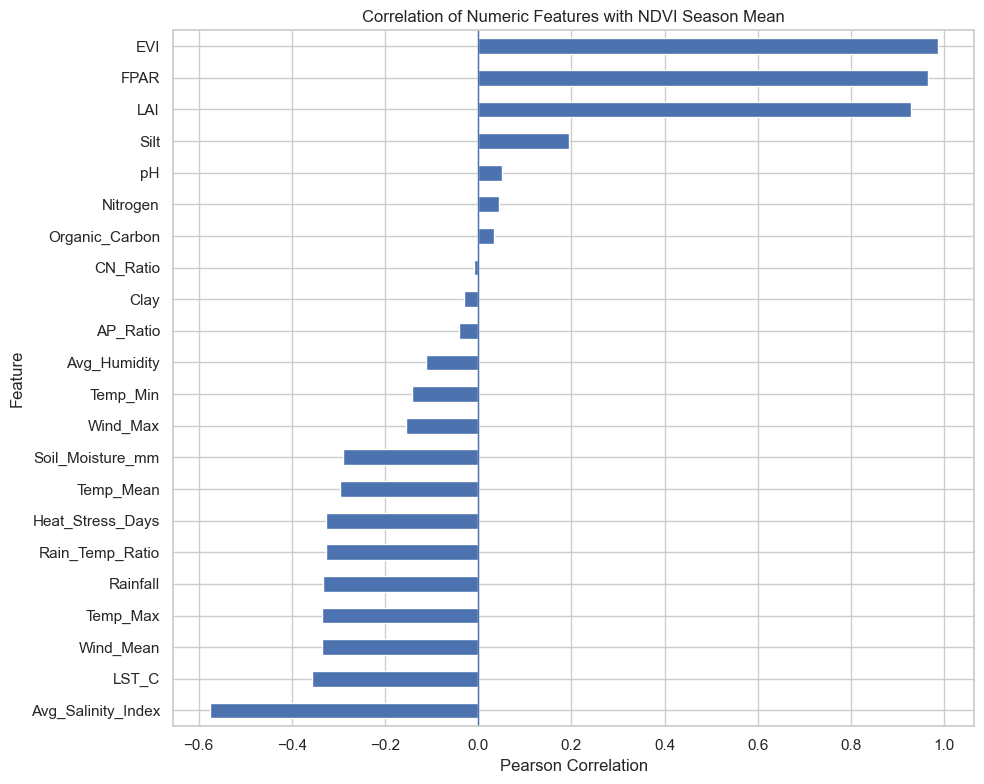

In [ ]:
numeric_df = df_eda.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

target_corr = corr_matrix[target].sort_values()
display(target_corr.to_frame("correlation_with_NDVI"))

plt.figure(figsize=(10, 8))
target_corr.drop(target).plot(kind="barh")
plt.title("Correlation of Numeric Features with NDVI Season Mean")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


def correlation_by_group(data, group_col, features, target_col):
    rows = []
    for group_name, group_df in data.groupby(group_col):
        for feature in features:
            if group_df[feature].nunique(dropna=True) <= 1:
                corr = np.nan
            else:
                corr = group_df[[feature, target_col]].corr().iloc[0, 1]
            rows.append({
                group_col: group_name,
                "feature": feature,
                "correlation": corr,
                "n": len(group_df),
            })
    return pd.DataFrame(rows)

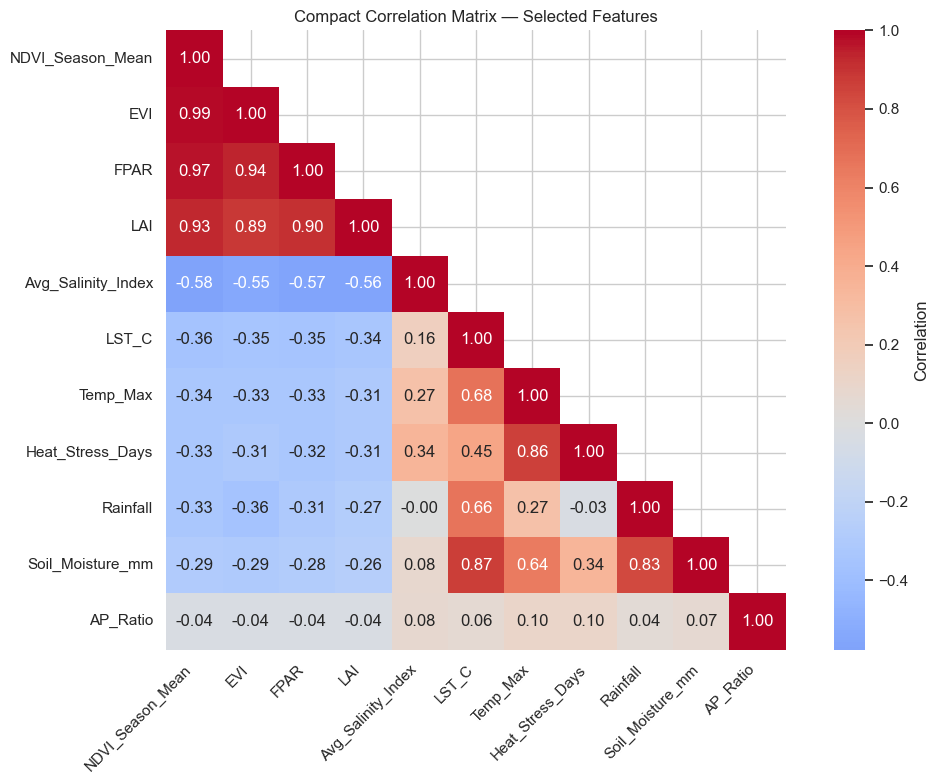

In [ ]:
selected_features = [
    target,
    "EVI",
    "FPAR",
    "LAI",
    "Avg_Salinity_Index",
    "LST_C",
    "Temp_Max",
    "Heat_Stress_Days",
    "Rainfall",
    "Soil_Moisture_mm",
    "AP_Ratio",
]

compact_corr = corr_matrix.loc[selected_features, selected_features]
mask = np.triu(np.ones_like(compact_corr, dtype=bool), k=1)

plt.figure(figsize=(11, 8))
sns.heatmap(
    compact_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Compact Correlation Matrix — Selected Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét**

- `EVI`, `FPAR` và `LAI` có tương quan dương rất cao với NDVI.
- `Avg_Salinity_Index` là biến môi trường có tương quan âm rõ nhất.
- Một số biến thời tiết có correlation âm ở dữ liệu tổng thể, nhưng cần kiểm tra theo Season trước khi diễn giải.
- Heatmap được rút gọn về các biến quan trọng để dễ đọc khi thuyết trình; ma trận đầy đủ có thể để ở phần phụ lục.

### 7.1. Kiểm tra proxy features và nguy cơ leakage theo thời gian

`EVI`, `FPAR`, `LAI` không chỉ là các biến có multicollinearity cao; chúng có thể là **proxy trực tiếp** của NDVI nếu được tạo từ cùng nguồn ảnh vệ tinh và cùng thời gian.

| Nhóm feature | Ví dụ | Câu hỏi trước modeling | Cách sử dụng đề xuất |
|---|---|---|---|
| Biết trước mùa vụ | District, Crop, Season, soil properties | Có sẵn tại thời điểm prediction không? | Có thể dùng trong forecasting model |
| Thu thập trong mùa | Rainfall, temperature, soil moisture | Dữ liệu đã có đến thời điểm dự đoán chưa? | Chỉ dùng phần lịch sử có sẵn |
| Chỉ số thực vật cùng thời điểm | EVI, FPAR, LAI | Có được tính cùng thời gian/nguồn với NDVI không? | So sánh model có và không có nhóm này |

**Quyết định:** Xây hai feature sets:  
1. Full-feature model có EVI/FPAR/LAI.  
2. Forecasting model không có các proxy cùng thời điểm.  

Khoảng cách hiệu năng giữa hai model sẽ cho biết model đang học từ điều kiện nông nghiệp hay chủ yếu tái tạo NDVI từ các chỉ số thực vật tương đồng.

## 8. Độ mặn và NDVI

Độ mặn có correlation âm rõ với NDVI. Để kiểm tra quan hệ này có chỉ do khác biệt Season hay không, cần tính correlation trong từng Season.

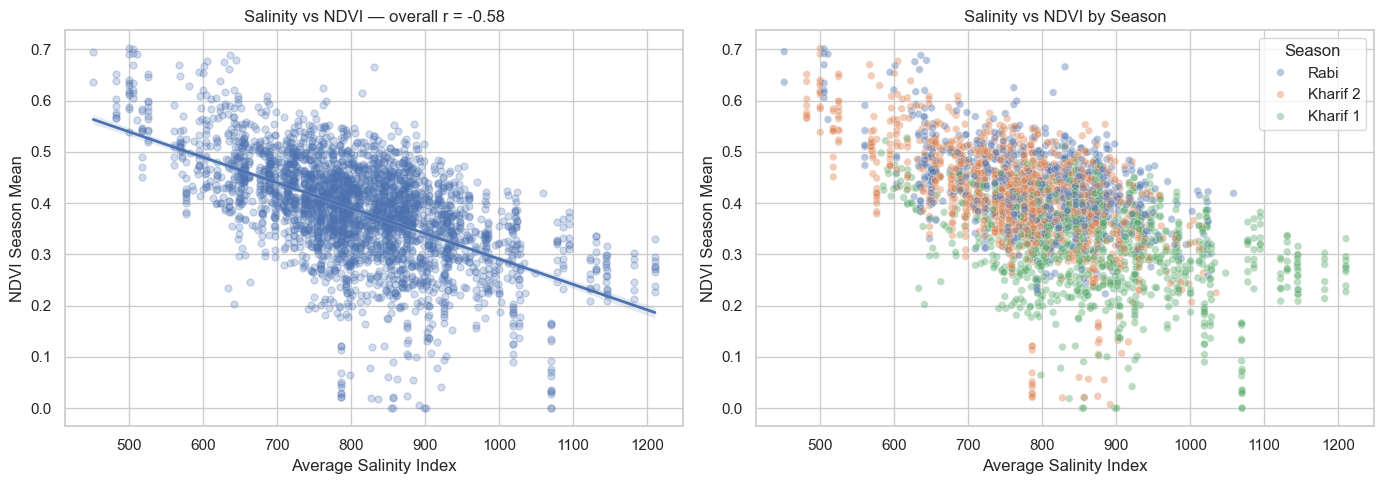

feature,Avg_Salinity_Index
Season,
Kharif 1,-0.3471
Kharif 2,-0.5699
Rabi,-0.5639


,count,mean_ndvi,mean_salinity,mean_soil_moisture,mean_temp_max,mean_rainfall,mean_heat_stress_days
Season,,,,,,,
Rabi,2780,0.4362,788.2006,10.5379,30.3261,109.0475,0.0000
Kharif 2,3892,0.4176,764.3026,25.7782,34.2378,"1,235.2512",1.2816
Kharif 1,3326,0.3121,873.5459,26.8230,39.6250,"1,089.1702",38.4020


In [ ]:
x_col = "Avg_Salinity_Index"
corr_value = df_eda[[x_col, target]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_eda.sample(min(3000, len(df_eda)), random_state=42),
    x=x_col,
    y=target,
    scatter_kws={"alpha": 0.25, "s": 25},
    line_kws={"linewidth": 2},
    ax=axes[0],
)
axes[0].set_title(f"Salinity vs NDVI — overall r = {corr_value:.2f}")
axes[0].set_xlabel("Average Salinity Index")
axes[0].set_ylabel("NDVI Season Mean")

sns.scatterplot(
    data=df_eda.sample(min(3000, len(df_eda)), random_state=42),
    x=x_col,
    y=target,
    hue="Season",
    alpha=0.4,
    s=30,
    ax=axes[1],
)
axes[1].set_title("Salinity vs NDVI by Season")
axes[1].set_xlabel("Average Salinity Index")
axes[1].set_ylabel("NDVI Season Mean")
axes[1].legend(title="Season")

plt.tight_layout()
plt.show()

salinity_by_season = correlation_by_group(
    df_eda,
    "Season",
    ["Avg_Salinity_Index"],
    target,
)
display(salinity_by_season.pivot(index="Season", columns="feature", values="correlation"))

season_env_summary = (
    df_eda.groupby("Season")
    .agg(
        count=(target, "count"),
        mean_ndvi=(target, "mean"),
        mean_salinity=("Avg_Salinity_Index", "mean"),
        mean_soil_moisture=("Soil_Moisture_mm", "mean"),
        mean_temp_max=("Temp_Max", "mean"),
        mean_rainfall=("Rainfall", "mean"),
        mean_heat_stress_days=("Heat_Stress_Days", "mean"),
    )
    .sort_values("mean_ndvi", ascending=False)
)
display(season_env_summary)

**Nhận xét**

- Toàn bộ dữ liệu cho thấy salinity tăng thường đi kèm NDVI giảm.
- Quan hệ âm vẫn xuất hiện trong cả ba Season, nên tín hiệu của salinity ổn định hơn nhiều biến thời tiết khác.
- Đây vẫn là association, không chứng minh độ mặn là nguyên nhân duy nhất.

**Liên hệ model:** Giữ `Avg_Salinity_Index` trong feature set và kiểm tra permutation importance hoặc SHAP sau training để xác nhận model có sử dụng tín hiệu này hay không.

## 9. Nhiệt độ, stress nhiệt và NDVI — kiểm tra confounding theo Season

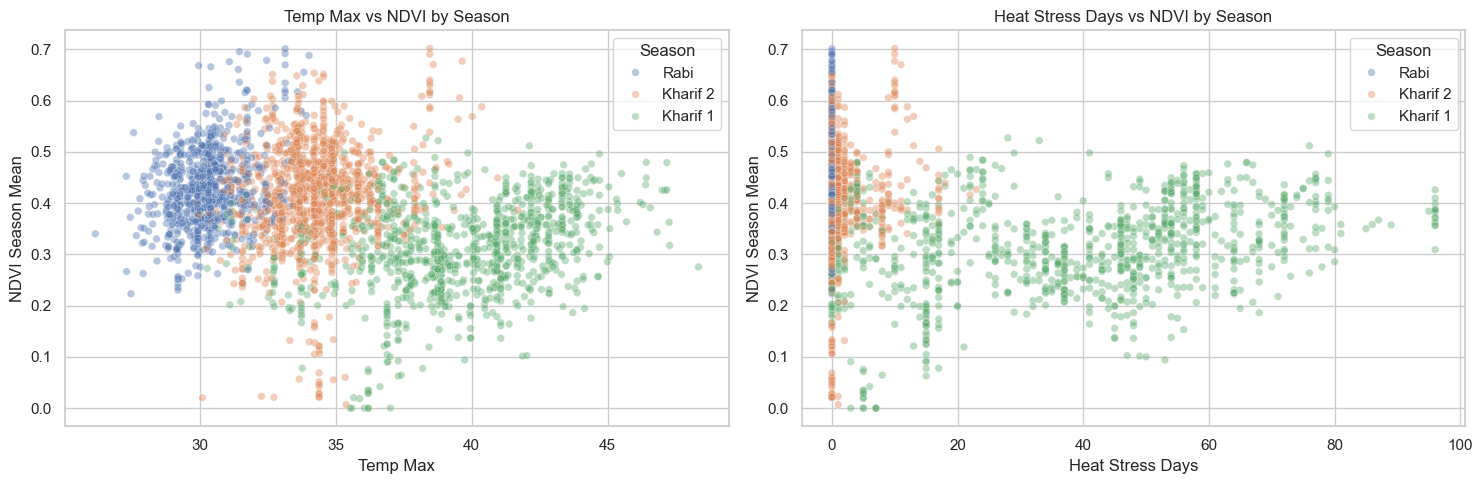

,overall_correlation
Temp_Max,-0.3359
Temp_Mean,-0.2960
LST_C,-0.3570
Heat_Stress_Days,-0.3255


feature,Heat_Stress_Days,LST_C,Temp_Max,Temp_Mean
Season,,,,
Kharif 1,0.2766,-0.0565,0.2727,0.1963
Kharif 2,0.0882,-0.2375,0.0804,-0.0535
Rabi,NaN,-0.1716,0.3457,-0.0471


In [ ]:
sampled = df_eda.sample(min(3000, len(df_eda)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=sampled,
    x="Temp_Max",
    y=target,
    hue="Season",
    alpha=0.4,
    s=30,
    ax=axes[0],
)
axes[0].set_title("Temp Max vs NDVI by Season")
axes[0].set_xlabel("Temp Max")
axes[0].set_ylabel("NDVI Season Mean")

sns.scatterplot(
    data=sampled,
    x="Heat_Stress_Days",
    y=target,
    hue="Season",
    alpha=0.4,
    s=30,
    ax=axes[1],
)
axes[1].set_title("Heat Stress Days vs NDVI by Season")
axes[1].set_xlabel("Heat Stress Days")
axes[1].set_ylabel("NDVI Season Mean")

plt.tight_layout()
plt.show()

temperature_features = ["Temp_Max", "Temp_Mean", "LST_C", "Heat_Stress_Days"]

overall_temperature_corr = (
    df_eda[[target] + temperature_features]
    .corr()[target]
    .drop(target)
    .rename("overall_correlation")
)
display(overall_temperature_corr.to_frame())

temperature_by_season = correlation_by_group(
    df_eda,
    "Season",
    temperature_features,
    target,
)
display(
    temperature_by_season.pivot(
        index="Season",
        columns="feature",
        values="correlation",
    )
)

**Nhận xét**

- Ở cấp độ toàn bộ dữ liệu, `Temp_Max`, `LST_C` và `Heat_Stress_Days` có correlation âm với NDVI.
- Tuy nhiên, khi phân tích trong từng Season, `Temp_Max` có correlation dương nhẹ hoặc trung bình; `Heat_Stress_Days` cũng đổi hướng trong các mùa có biến thiên.
- Điều này cho thấy correlation âm toàn cục phần lớn có thể do **Season confounding**: `Kharif 1` vừa nóng hơn, vừa có nhiều stress nhiệt hơn, đồng thời có NDVI thấp hơn.

**Kết luận đúng:** Không thể nói “nhiệt độ cao làm NDVI giảm” chỉ từ heatmap toàn bộ dữ liệu.

**Liên hệ model:** Giữ Season và các biến nhiệt độ, ưu tiên model có thể học interaction. Sau training, dùng SHAP dependence plot theo Season thay vì chỉ dựa vào correlation tổng thể.

## 10. Độ ẩm đất, lượng mưa và NDVI

Mối quan hệ với nước có thể phi tuyến và phụ thuộc mùa vụ, loại cây, đất hoặc ngập úng. Vì vậy, cần so sánh correlation toàn cục với correlation trong từng Season.

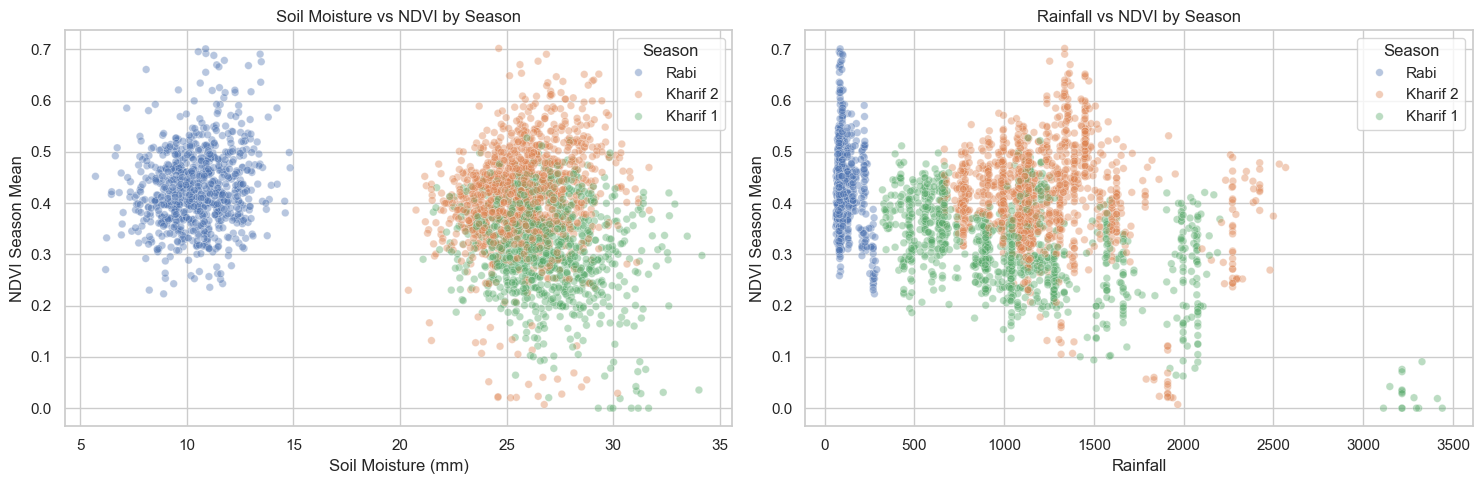

,overall_correlation
Soil_Moisture_mm,-0.2903
Rainfall,-0.3326
Rain_Temp_Ratio,-0.3270


feature,Rain_Temp_Ratio,Rainfall,Soil_Moisture_mm
Season,,,
Kharif 1,-0.5069,-0.5157,-0.1966
Kharif 2,-0.0912,-0.0985,0.2106
Rabi,-0.1488,-0.1588,0.2601


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=sampled,
    x="Soil_Moisture_mm",
    y=target,
    hue="Season",
    alpha=0.4,
    s=30,
    ax=axes[0],
)
axes[0].set_title("Soil Moisture vs NDVI by Season")
axes[0].set_xlabel("Soil Moisture (mm)")
axes[0].set_ylabel("NDVI Season Mean")

sns.scatterplot(
    data=sampled,
    x="Rainfall",
    y=target,
    hue="Season",
    alpha=0.4,
    s=30,
    ax=axes[1],
)
axes[1].set_title("Rainfall vs NDVI by Season")
axes[1].set_xlabel("Rainfall")
axes[1].set_ylabel("NDVI Season Mean")

plt.tight_layout()
plt.show()

water_features = ["Soil_Moisture_mm", "Rainfall", "Rain_Temp_Ratio"]

overall_water_corr = (
    df_eda[[target] + water_features]
    .corr()[target]
    .drop(target)
    .rename("overall_correlation")
)
display(overall_water_corr.to_frame())

water_by_season = correlation_by_group(
    df_eda,
    "Season",
    water_features,
    target,
)
display(
    water_by_season.pivot(
        index="Season",
        columns="feature",
        values="correlation",
    )
)

**Nhận xét**

- `Soil_Moisture_mm` và `Rainfall` có correlation âm trong dữ liệu tổng thể.
- `Rabi` có lượng mưa và độ ẩm thấp hơn nhưng NDVI trung bình cao hơn, trong khi `Kharif 1` có mưa/ẩm cao hơn và NDVI thấp hơn.
- Vì vậy, không nên kết luận “nhiều nước làm NDVI giảm”. Quan hệ tổng thể có thể phản ánh khác biệt mùa vụ, loại cây, nhiệt độ, salinity hoặc ngập úng.

**Liên hệ model:** Giữ các biến nước để tree model kiểm tra quan hệ phi tuyến và interaction. Không loại feature chỉ vì correlation toàn cục trái với kỳ vọng nghiệp vụ.

## 11. Phân phối lệch và outlier của AP_Ratio

`AP_Ratio` là feature đầu vào, không phải target. Feature này có phân phối lệch phải rất mạnh nên cần kiểm tra tính hợp lệ và thử nhiều chiến lược thay vì tự động cap.

,AP_Ratio
count,"9,998.0000"
mean,4.6326
std,16.9883
min,0.0000
50%,2.5255
75%,4.3426
90%,8.7560
95%,14.5765
99%,28.7484
max,989.3712


,AP_Ratio,District,Season,Crop_Name,Rainfall,Temp_Mean,NDVI_Season_Mean
5614,989.3712,Netrokona,Kharif 1,Jack Fruit,"2,005.8100",27.7371,0.1818
7178,951.2167,Netrokona,Kharif 1,Jack Fruit,"1,997.2200",27.3141,0.1613
8633,291.9018,Jamalpur,Kharif 1,Jack Fruit,"1,300.0900",28.5528,0.2856
3354,286.9471,Kushtia,Kharif 1,Jack Fruit,619.8600,29.5153,0.4374
1010,286.8100,Jamalpur,Kharif 1,Jack Fruit,"1,278.2200",28.1570,0.2583
6979,275.8533,Kushtia,Kharif 1,Jack Fruit,638.5700,29.1759,0.4289
9916,228.2512,Sirajganj,Kharif 1,Jack Fruit,"1,008.2000",27.9027,0.2608
3192,207.9147,Sirajganj,Kharif 1,Jack Fruit,"1,047.5600",27.6917,0.3054
4139,204.1359,Sirajganj,Kharif 1,Jack Fruit,"1,011.4400",28.6632,0.2586
3908,201.7979,Sirajganj,Kharif 1,Jack Fruit,"1,038.7900",28.6633,0.2800


,count,median,mean,max
Crop_Name,,,,
Jack Fruit,139,21.9782,60.0892,989.3712
Sugarcane,139,15.2029,14.9035,29.6314
Ripe Papaya,139,15.0157,16.5846,52.1221
Green Papaya,138,13.0078,14.8404,90.0000
Green Coconut,138,9.9560,12.4455,98.9907
Jambura,139,6.6292,8.3125,34.3966
Green Palmyra,139,6.3659,9.9878,54.5690
Mango,139,6.1319,7.3402,30.5013
Cabbage,139,6.0757,6.2383,14.0982


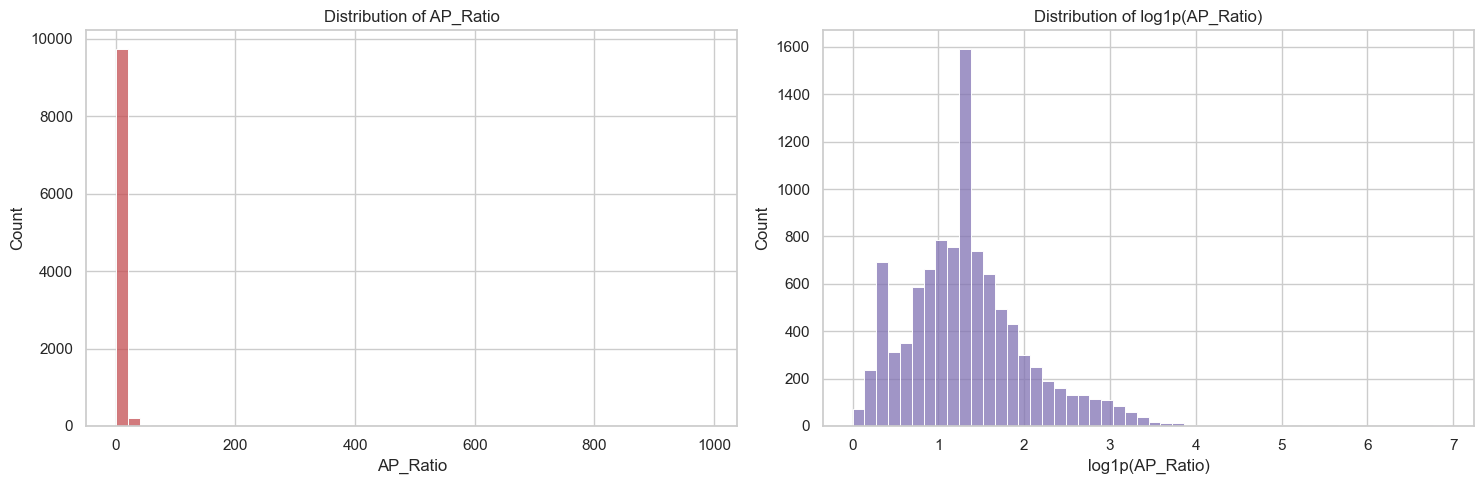

Pearson correlation AP_Ratio vs NDVI: -0.0404
Pearson correlation log1p(AP_Ratio) vs NDVI: -0.0560


In [ ]:
display(
    df_eda["AP_Ratio"]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame()
)

top_ap = (
    df_eda[
        [
            "AP_Ratio",
            "District",
            "Season",
            "Crop_Name",
            "Rainfall",
            "Temp_Mean",
            target,
        ]
    ]
    .sort_values("AP_Ratio", ascending=False)
    .head(15)
)
display(top_ap)

ap_crop_summary = (
    df_eda.groupby("Crop_Name")["AP_Ratio"]
    .agg(count="size", median="median", mean="mean", max="max")
    .sort_values("median", ascending=False)
    .head(15)
)
display(ap_crop_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_eda["AP_Ratio"], bins=50, color="#C44E52", ax=axes[0])
axes[0].set_title("Distribution of AP_Ratio")
axes[0].set_xlabel("AP_Ratio")

sns.histplot(np.log1p(df_eda["AP_Ratio"]), bins=50, color="#8172B3", ax=axes[1])
axes[1].set_title("Distribution of log1p(AP_Ratio)")
axes[1].set_xlabel("log1p(AP_Ratio)")

plt.tight_layout()
plt.show()

print(
    "Pearson correlation AP_Ratio vs NDVI:",
    f"{df_eda[['AP_Ratio', target]].corr().iloc[0, 1]:.4f}",
)
print(
    "Pearson correlation log1p(AP_Ratio) vs NDVI:",
    f"{np.corrcoef(np.log1p(df_eda['AP_Ratio']), df_eda[target])[0, 1]:.4f}",
)

**Nhận xét**

- `AP_Ratio` có median thấp nhưng max rất lớn; các giá trị cao tập trung ở một số loại cây, nên chúng có thể là pattern có cấu trúc chứ không phải noise ngẫu nhiên.
- Không nên mặc định winsorize bằng ngưỡng IQR toàn cục vì có thể xóa khác biệt thật giữa các crop.
- Vì đây là feature của tree-based model, skewness không bắt buộc phải được xử lý.

**Quyết định thử nghiệm:** So sánh bằng cross-validation ba phiên bản:  
1. `AP_Ratio` gốc.  
2. `log1p(AP_Ratio)`.  
3. Loại `AP_Ratio`.  

Chỉ giữ transformation nếu cải thiện metric và vẫn phù hợp nghiệp vụ.

## 12. Tổng kết EDA → Preprocessing → Model

In [ ]:
eda_decisions = pd.DataFrame([
    {
        "EDA finding": "2 dòng Crop_Name = #REF!",
        "Risk / meaning": "Category không hợp lệ",
        "Preprocessing decision": "Sửa từ nguồn hoặc loại 2 dòng",
        "Model implication": "Tránh tạo category rác",
    },
    {
        "EDA finding": "Target khá cân đối, mean gần median",
        "Risk / meaning": "Không có skew mạnh ở target",
        "Preprocessing decision": "Giữ NDVI trên thang gốc",
        "Model implication": "Báo cáo MAE theo đơn vị NDVI",
    },
    {
        "EDA finding": "12 dòng NDVI = 0 có pattern nhất quán",
        "Risk / meaning": "Có thể là vegetation rất thấp, không phải lỗi",
        "Preprocessing decision": "Không tự động xóa; xác minh nguồn",
        "Model implication": "Giữ các trường hợp khó trong evaluation",
    },
    {
        "EDA finding": "EVI, FPAR, LAI gần target",
        "Risk / meaning": "Proxy / leakage theo thời gian",
        "Preprocessing decision": "Tạo feature set có và không có proxy",
        "Model implication": "So sánh full model với forecasting model",
    },
    {
        "EDA finding": "Salinity liên hệ âm trong cả ba Season",
        "Risk / meaning": "Tín hiệu môi trường tương đối ổn định",
        "Preprocessing decision": "Giữ feature; kiểm tra phạm vi",
        "Model implication": "Kiểm tra SHAP / permutation importance",
    },
    {
        "EDA finding": "Quan hệ nhiệt độ thay đổi theo Season",
        "Risk / meaning": "Confounding và interaction",
        "Preprocessing decision": "Giữ Season và weather features",
        "Model implication": "Ưu tiên tree-based model",
    },
    {
        "EDA finding": "Mỗi Crop chỉ nằm trong một Season/Growth",
        "Risk / meaning": "Categorical features phụ thuộc mạnh",
        "Preprocessing decision": "Encode trong pipeline; không diễn giải nhân quả",
        "Model implication": "Feature importance có thể bị chia sẻ",
    },
    {
        "EDA finding": "District khác biệt rõ",
        "Risk / meaning": "Khả năng shift theo địa lý",
        "Preprocessing decision": "Mọi encoding phải nằm trong CV",
        "Model implication": "GroupKFold theo District nếu dự đoán khu vực mới",
    },
    {
        "EDA finding": "AP_Ratio lệch phải mạnh",
        "Risk / meaning": "Outlier có cấu trúc theo crop",
        "Preprocessing decision": "So sánh raw / log1p / drop",
        "Model implication": "Không cap mặc định trước CV",
    },
])

display(eda_decisions)

,EDA finding,Risk / meaning,Preprocessing decision,Model implication
0,2 dòng Crop_Name = #REF!,Category không hợp lệ,Sửa từ nguồn hoặc loại 2 dòng,Tránh tạo category rác
1,"Target khá cân đối, mean gần median",Không có skew mạnh ở target,Giữ NDVI trên thang gốc,Báo cáo MAE theo đơn vị NDVI
2,12 dòng NDVI = 0 có pattern nhất quán,"Có thể là vegetation rất thấp, không phải lỗi",Không tự động xóa; xác minh nguồn,Giữ các trường hợp khó trong evaluation
3,"EVI, FPAR, LAI gần target",Proxy / leakage theo thời gian,Tạo feature set có và không có proxy,So sánh full model với forecasting model
4,Salinity liên hệ âm trong cả ba Season,Tín hiệu môi trường tương đối ổn định,Giữ feature; kiểm tra phạm vi,Kiểm tra SHAP / permutation importance
5,Quan hệ nhiệt độ thay đổi theo Season,Confounding và interaction,Giữ Season và weather features,Ưu tiên tree-based model
6,Mỗi Crop chỉ nằm trong một Season/Growth,Categorical features phụ thuộc mạnh,Encode trong pipeline; không diễn giải nhân quả,Feature importance có thể bị chia sẻ
7,District khác biệt rõ,Khả năng shift theo địa lý,Mọi encoding phải nằm trong CV,GroupKFold theo District nếu dự đoán khu vực mới
8,AP_Ratio lệch phải mạnh,Outlier có cấu trúc theo crop,So sánh raw / log1p / drop,Không cap mặc định trước CV


## Kết luận dùng khi thuyết trình

> EDA cho thấy NDVI có phân phối tương đối cân đối, nhưng chịu ảnh hưởng đồng thời của mùa vụ, khu vực, loại cây và điều kiện môi trường. Salinity có mối liên hệ âm tương đối ổn định, trong khi quan hệ giữa nhiệt độ, lượng mưa và NDVI thay đổi khi phân tách theo Season, cho thấy tồn tại confounding và interaction. EVI, FPAR và LAI là các proxy rất mạnh của NDVI nên nhóm sẽ so sánh model có và không có các feature này để kiểm soát nguy cơ leakage theo thời gian. Từ đó, nhóm lựa chọn pipeline chống leakage, GroupKFold theo District và các tree-based models để học quan hệ phi tuyến.